In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 3.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import adfuller

from pmdarima import auto_arima

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("master_influenza_dataset.csv")

# Convert date
df['Date'] = pd.to_datetime(df['Date'])

df.head()

,Year,Week,ILI_Total,Total_Patients,Weighted_ILI,Region,Season,Date,Population_2024,ILI_per_100k
0,2019,40,5637,333469,1.67601,Region 4,2019_20,2019-09-30,70994814.0,7.940017
1,2019,41,5349,317260,1.63170,Region 4,2019_20,2019-10-07,70994814.0,7.534353
2,2019,42,5711,311644,1.81532,Region 4,2019_20,2019-10-14,70994814.0,8.044250
3,2019,43,6683,322052,1.96609,Region 4,2019_20,2019-10-21,70994814.0,9.413364
4,2019,44,7119,318970,2.29988,Region 4,2019_20,2019-10-28,70994814.0,10.027493


In [ ]:
print(df.columns)
print(df['Region'].unique())

Index(['Year', 'Week', 'ILI_Total', 'Total_Patients', 'Weighted_ILI', 'Region',
       'Season', 'Date', 'Population_2024', 'ILI_per_100k'],
      dtype='object')
['Region 4' 'Region 6' 'Region 9']


In [ ]:
region = 'Region 4'   # ✅ IMPORTANT FIX

data = df[df['Region'] == region].copy()
data = data.sort_values('Date')
data.set_index('Date', inplace=True)

print(data.shape)
data.head()

(260, 9)


,Year,Week,ILI_Total,Total_Patients,Weighted_ILI,Region,Season,Population_2024,ILI_per_100k
Date,,,,,,,,,
2019-09-30,2019,40,5637,333469,1.67601,Region 4,2019_20,70994814.0,7.940017
2019-10-07,2019,41,5349,317260,1.63170,Region 4,2019_20,70994814.0,7.534353
2019-10-14,2019,42,5711,311644,1.81532,Region 4,2019_20,70994814.0,8.044250
2019-10-21,2019,43,6683,322052,1.96609,Region 4,2019_20,70994814.0,9.413364
2019-10-28,2019,44,7119,318970,2.29988,Region 4,2019_20,70994814.0,10.027493


In [ ]:
# Clean columns
df.columns = df.columns.str.strip()

# Find correct column automatically
col_name = [col for col in df.columns if 'weight' in col.lower()][0]

print("Using column:", col_name)

ts = data[col_name]
ts = ts.fillna(method='ffill')
ts = np.log1p(ts)

Using column: Weighted_ILI


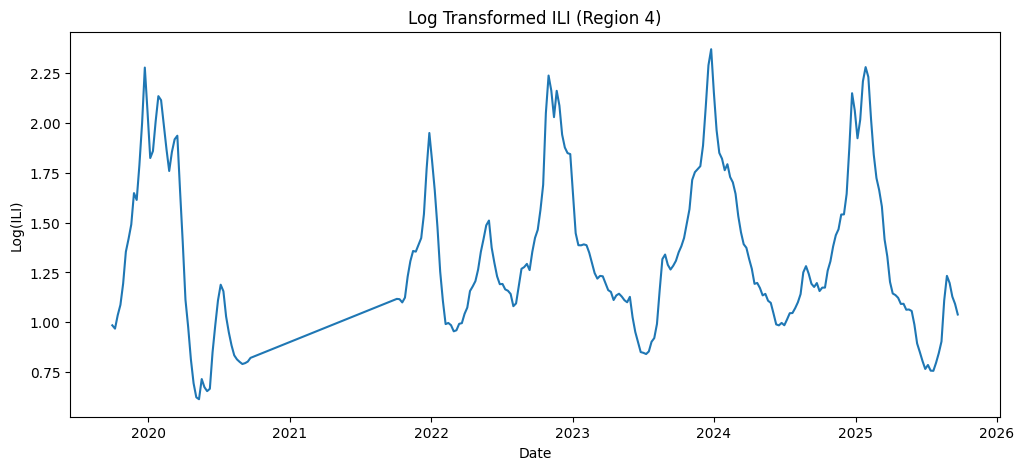

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(ts)
plt.title(f"Log Transformed ILI ({region})")
plt.xlabel("Date")
plt.ylabel("Log(ILI)")
plt.show()

In [ ]:
result = adfuller(ts.dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -4.161928328197356
p-value: 0.0007637990186788308


In [ ]:
train_size = int(len(ts) * 0.8)

train = ts[:train_size]
test = ts[train_size:]

print(len(train), len(test))

208 52


In [ ]:
model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,0,52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit()
print(results.summary())

                                      SARIMAX Results                                      
Dep. Variable:                        Weighted_ILI   No. Observations:                  208
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 52)   Log Likelihood                 121.477
Date:                             Tue, 28 Apr 2026   AIC                           -234.954
Time:                                     15:30:18   BIC                           -224.454
Sample:                                          0   HQIC                          -230.702
                                             - 208                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3070      0.111      2.763      0.006       0.089       0.525
ma.L1          0.3370      

In [ ]:
forecast = results.predict(
    start=len(train),
    end=len(train) + len(test) - 1,
    dynamic=False
)

# Convert back from log
forecast = np.expm1(forecast)
test_actual = np.expm1(test)

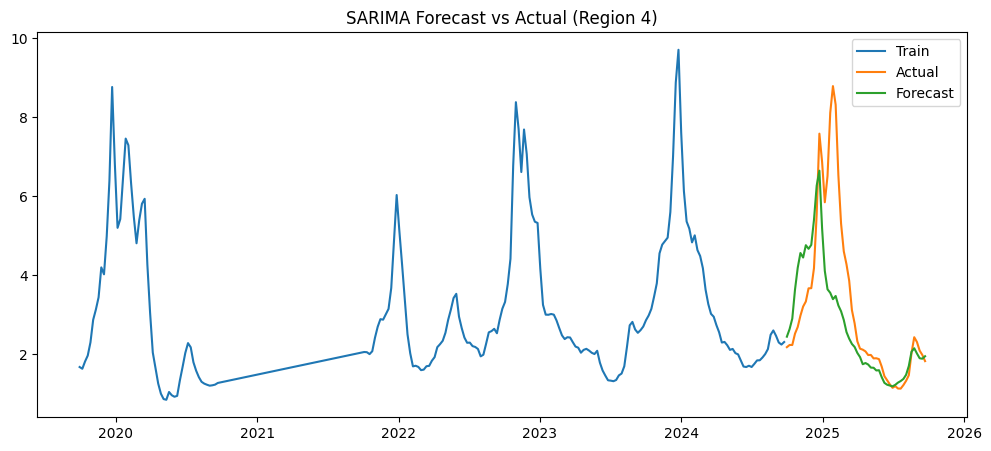

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(train.index, np.expm1(train), label='Train')
plt.plot(test.index, test_actual, label='Actual')
plt.plot(test.index, forecast, label='Forecast')

plt.legend()
plt.title(f"SARIMA Forecast vs Actual ({region})")
plt.show()

In [ ]:
rmse = np.sqrt(mean_squared_error(test_actual, forecast))
print("RMSE:", rmse)

RMSE: 1.5756786200034427


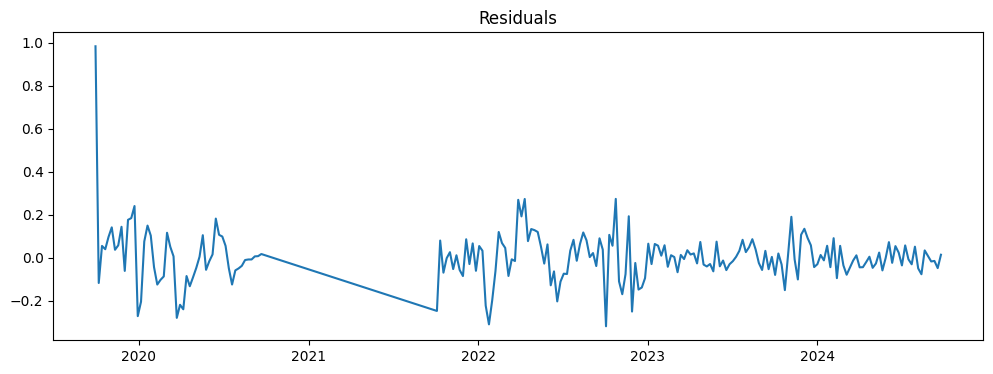

In [ ]:
residuals = results.resid

plt.figure(figsize=(12,4))
plt.plot(residuals)
plt.title("Residuals")
plt.show()

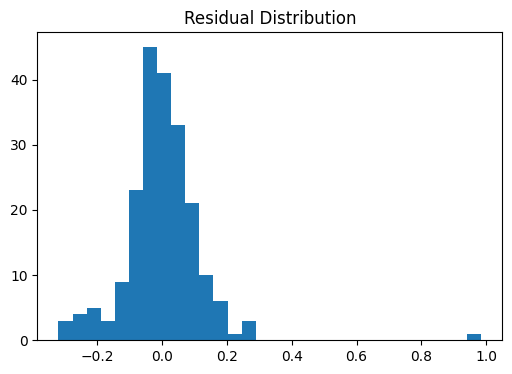

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.show()

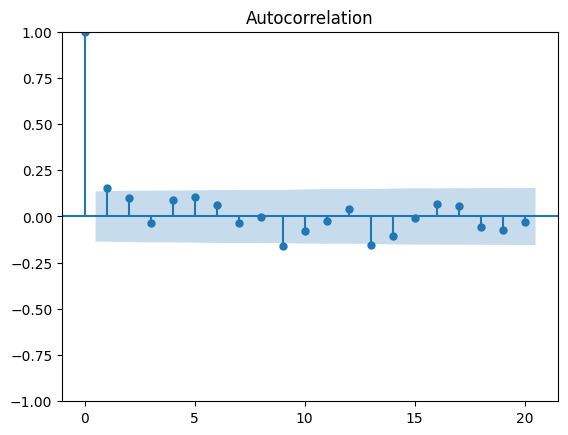

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(residuals, lags=20)
plt.show()

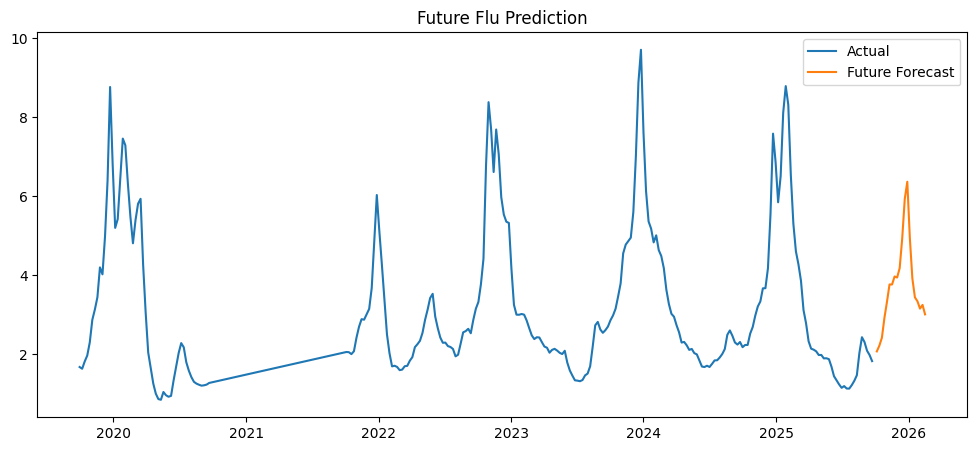

In [ ]:
future_steps = 20

future_forecast = results.predict(
    start=len(ts),
    end=len(ts) + future_steps - 1,
    dynamic=False
)

future_forecast = np.expm1(future_forecast)

# Future dates
future_dates = pd.date_range(start=ts.index[-1], periods=future_steps+1, freq='W')[1:]

plt.figure(figsize=(12,5))

plt.plot(np.expm1(ts), label='Actual')
plt.plot(future_dates, future_forecast, label='Future Forecast')

plt.legend()
plt.title("Future Flu Prediction")
plt.show()